# Siamese Metric Learner Contrastive Network

Siamese Neural Networks evaluate feature distances between coordinate pairs by running them through identical weight-sharing networks. By utilizing **Contrastive Loss**, they optimize representations so that similar pairs are mapped close to each other in latent space, while dissimilar pairs are pushed apart by a specified margin. This notebook builds a Siamese Network in PyTorch, trains it on a synthetic 16-dimensional dataset, and visualizes latent margins in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate synthetic pairwise distance inputs (600 samples, 16 features, 4 latent dimensions)
np.random.seed(255)
n_pairs = 600
input_dim = 16

# Base features
X1 = np.random.normal(0, 1.0, (n_pairs, input_dim))
X2 = np.random.normal(0, 1.0, (n_pairs, input_dim))

# Label indicates similarity: 1 = similar (close distance), 0 = dissimilar (far distance)
# Similar pairs are created by replacing half of X2 values with X1 values + minor noise
y_labels = np.random.randint(0, 2, n_pairs)

for idx, label in enumerate(y_labels):
    if label == 1:
        X2[idx] = X1[idx] + np.random.normal(0, 0.25, input_dim)

X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(X1, X2, y_labels, test_size=0.2, random_state=42)

X1_tr_t = torch.FloatTensor(X1_train)
X2_tr_t = torch.FloatTensor(X2_train)
y_tr_t = torch.FloatTensor(y_train)

X1_te_t = torch.FloatTensor(X1_test)
X2_te_t = torch.FloatTensor(X2_test)
y_te_t = torch.FloatTensor(y_test)

print("Input Pair 1 Train Shape:", X1_tr_t.shape)
print("Input Pair 2 Train Shape:", X2_tr_t.shape)



Input Pair 1 Train Shape: torch.Size([480, 16])
Input Pair 2 Train Shape: torch.Size([480, 16])


## Shared Weight Siamese Architecture

We implement the Siamese Net in PyTorch with a custom Contrastive Loss function.



In [2]:
class SiameseBase(nn.Module):
    def __init__(self, in_dim=16, latent_dim=4):
        super(SiameseBase, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

# Custom Contrastive Loss: similar pairs minimize distance; dissimilar pairs maximize distance up to a margin
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
        
    def forward(self, z1, z2, label):
        euclidean_distance = nn.functional.pairwise_distance(z1, z2)
        # Similar pairs loss
        loss_similar = label * euclidean_distance.pow(2)
        # Dissimilar pairs loss (clamped at margin)
        loss_dissimilar = (1.0 - label) * torch.clamp(self.margin - euclidean_distance, min=0.0).pow(2)
        
        return torch.mean(loss_similar + loss_dissimilar)

model = SiameseBase()
criterion = ContrastiveLoss(margin=1.5)
optimizer = optim.Adam(model.parameters(), lr=0.005)



## Siamese Network Training

We train the networks for 120 epochs, monitoring contrastive loss reduction.



In [3]:
epochs = 120
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    z1 = model(X1_tr_t)
    z2 = model(X2_tr_t)
    
    loss = criterion(z1, z2, y_tr_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | Contrastive Loss: {loss.item():.4f}")



Epoch  20/120 | Contrastive Loss: 0.0865
Epoch  40/120 | Contrastive Loss: 0.0645
Epoch  60/120 | Contrastive Loss: 0.0489
Epoch  80/120 | Contrastive Loss: 0.0426
Epoch 100/120 | Contrastive Loss: 0.0391
Epoch 120/120 | Contrastive Loss: 0.0369


## Latent Distance Distributions

We evaluate the pairwise Euclidean distances in latent space for test similar vs. dissimilar pairs and visualize them using a Matplotlib histogram.



Siamese Similarity Classification Accuracy: 97.50%


<cell>:25: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



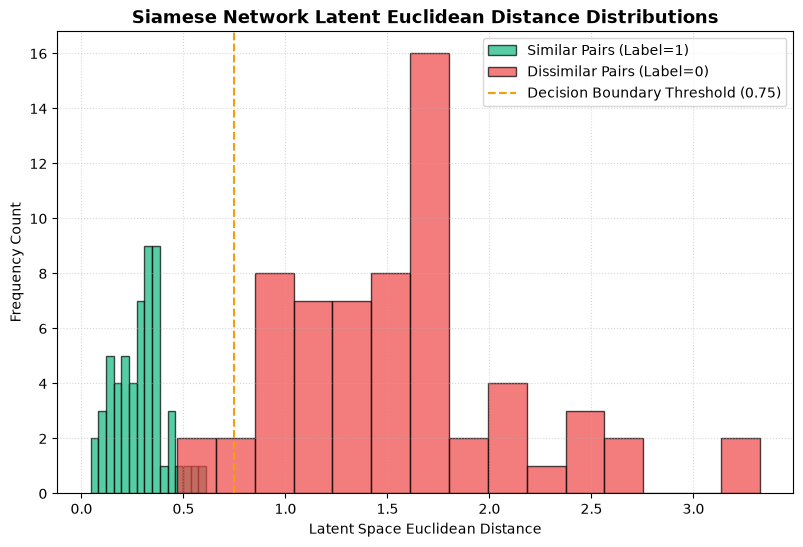

In [4]:
model.eval()
with torch.no_grad():
    z1_test = model(X1_te_t)
    z2_test = model(X2_te_t)
    
    test_dists = nn.functional.pairwise_distance(z1_test, z2_test).numpy()

# Calculate classification accuracy based on distance threshold cut at 0.75
predictions = (test_dists < 0.75).astype(int)
accuracy = np.mean(predictions == y_test)
print(f"Siamese Similarity Classification Accuracy: {accuracy*100:.2f}%")

plt.figure(figsize=(9.5, 6))

plt.hist(test_dists[y_test == 1], bins=15, color='#10B981', alpha=0.7, edgecolor='black', label='Similar Pairs (Label=1)')
plt.hist(test_dists[y_test == 0], bins=15, color='#EF4444', alpha=0.7, edgecolor='black', label='Dissimilar Pairs (Label=0)')

plt.axvline(0.75, color='#F59E0B', linestyle='--', linewidth=1.5, label='Decision Boundary Threshold (0.75)')

plt.title('Siamese Network Latent Euclidean Distance Distributions', fontsize=13, fontweight='bold')
plt.xlabel('Latent Space Euclidean Distance')
plt.ylabel('Frequency Count')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
